In [26]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from tensorflow.keras import regularizers
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report
from sklearn.linear_model import LogisticRegression


In [27]:
# Merged Dataset Making

# Define column names for UCI_df as it doesn't have a header
uci_column_names = ['age', 'menopause', 'tumor-size', 'nodes', 'node-caps',
                    'stage', 'breast', 'breast-quad', 'irradiat', 'class']

UCI_df = pd.read_csv('/content/breast-cancer-data.csv', names=uci_column_names)
UCI_df = UCI_df.iloc[1:].reset_index(drop=True)
german_df = pd.read_csv('/content/gbsg.csv')

# renaming feature columns so the names match at merging
UCI_df = UCI_df.rename(columns={
    'age': 'age',
    'menopause': 'menopause',
    'tumer-size':'tumor-size',
    'deg-malig':'stage',
    'class':'class',
    })

german_df = german_df.rename(columns={
    'age': 'age',
    'meno': 'menopause',
    'size':'tumor-size',
    'grade':'stage',
    'status':'class',
    })


# Replace deprecated applymap with explicit column-wise string cleaning for object columns
for col in UCI_df.columns:
    if UCI_df[col].dtype == 'object':
        UCI_df[col] = UCI_df[col].astype(str).str.replace("'", "").str.strip()

UCI_df['menopause'] = UCI_df['menopause'].replace({
    'premeno': 0,
    'ge40': 1,
    'lt40': 1
})

UCI_df['class'] = UCI_df['class'].replace({
    'no-recurrence-events': 0,
    'recurrence-events': 1
})


# changing fixed values to ranges
def age_to_range(age):
  if age <= 29:
    return "20-29"
  elif age <= 39:
    return "30-39"
  elif age <= 49:
    return "40-49"
  elif age <= 59:
    return "50-59"
  elif age <= 69:
    return "60-69"
  elif age <= 79:
    return "70-79"
  elif age <= 89:
    return "80-89"

def tumor_to_range(tumor):
  if tumor <= 4:
    return "0-4"
  elif tumor <= 9:
    return "5-9"
  elif tumor <= 14:
    return "10-14"
  elif tumor <= 19:
    return "15-19"
  elif tumor <= 24:
    return "20-24"
  elif tumor <= 29:
    return "25-29"
  elif tumor <= 34:
    return "30-34"
  elif tumor <= 39:
    return "35-39"
  elif tumor <= 44:
    return "40-44"
  elif tumor <= 49:
    return "45-49"
  elif tumor <= 54:
    return "50-54"
  elif tumor <= 59:
    return "55-59"
  elif tumor <= 64:
    return "60-64"
  elif tumor <= 69:
    return "65-69"
  elif tumor <= 74:
    return "70-74"
  elif tumor <= 79:
    return "75-79"
  elif tumor <= 84:
    return "80-84"
  elif tumor <= 89:
    return "85-89"
  elif tumor <= 94:
    return "90-94"
  elif tumor <= 99:
    return "95-99"
  elif tumor <= 100:
    return "100"


def node_to_range(node):
  if node <= 2:
    return "0-2"
  elif node <= 5:
    return "3-5"
  elif node <= 8:
    return "6-8"
  elif node <= 11:
    return "9-11"



german_df['age'] = german_df['age'].apply(age_to_range)
german_df['tumor-size'] = german_df['tumor-size'].apply(tumor_to_range)

# Keep only common columns
common_cols = list(set(UCI_df.columns).intersection(german_df.columns))
df1_common = UCI_df[common_cols]
df2_common = german_df[common_cols]


# Combine rows
merged_breast_cancer_df = pd.concat([df1_common, df2_common], ignore_index=True)
merged_breast_cancer_df = merged_breast_cancer_df.drop(columns = ['nodes'])
merged_breast_cancer_df = merged_breast_cancer_df.dropna(subset=['tumor-size'])
print(merged_breast_cancer_df.head())


encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_data = encoder.fit_transform(merged_breast_cancer_df[['age', 'tumor-size']]) # change to real column name
encoded = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(['age', 'tumor-size'])) # CHANGE TO REAL COLUMN NAME
encoded_df = merged_breast_cancer_df.join(encoded)
encoded_df = encoded_df.drop(['age', 'tumor-size'], axis=1)
columns = encoded_df.columns.tolist()
for column in columns:
  encoded_df[column] = pd.to_numeric(encoded_df[column])

print(encoded_df.head())



   class  menopause tumor-size stage    age
0      1          0      15-19     3  40-49
1      0          1      15-19     1  50-59
2      1          1      35-39     2  50-59
3      0          0      35-39     3  40-49
4      1          0      30-34     2  40-49
   class  menopause  stage  age_20-29  age_30-39  age_40-49  age_50-59  \
0      1          0      3        0.0        0.0        1.0        0.0   
1      0          1      1        0.0        0.0        0.0        1.0   
2      1          1      2        0.0        0.0        0.0        1.0   
3      0          0      3        0.0        0.0        1.0        0.0   
4      1          0      2        0.0        0.0        1.0        0.0   

   age_60-69  age_70-79  age_80-89  ...  tumor-size_40-44  tumor-size_45-49  \
0        0.0        0.0        0.0  ...               0.0               0.0   
1        0.0        0.0        0.0  ...               0.0               0.0   
2        0.0        0.0        0.0  ...               

/tmp/ipykernel_6706/3869159955.py:34: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  UCI_df['menopause'] = UCI_df['menopause'].replace({
/tmp/ipykernel_6706/3869159955.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  UCI_df['class'] = UCI_df['class'].replace({


In [28]:
# Make Baseline Model with merged data

#split into testing and training:
encoded_df_clean = encoded_df.dropna()
X = encoded_df_clean.drop('class', axis=1)
Y = encoded_df_clean['class']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=1)

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(max_iter=1000) # Increased max_iter for convergence
log_reg_model.fit(x_train, y_train)

# Make predictions on the test set
y_pred = log_reg_model.predict(x_test)

# Calculate the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Model Accuracy: {accuracy:.4f}")

Logistic Regression Model Accuracy: 0.5464


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.6095 - loss: 1.0184 - val_accuracy: 0.5825 - val_loss: 1.0116
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6108 - loss: 1.0045 - val_accuracy: 0.5825 - val_loss: 1.0011
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6108 - loss: 0.9914 - val_accuracy: 0.5825 - val_loss: 0.9905
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6108 - loss: 0.9790 - val_accuracy: 0.5825 - val_loss: 0.9806
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6108 - loss: 0.9669 - val_accuracy: 0.5825 - val_loss: 0.9719
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6108 - loss: 0.9561 - val_accuracy: 0.5825 - val_loss: 0.9647
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6108 - loss: 0.9461 - val_accuracy: 0.5825 - val_loss: 0.9579
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6108 - loss: 0.9373 - val_accuracy: 0.5825 - val_loss: 0.9505


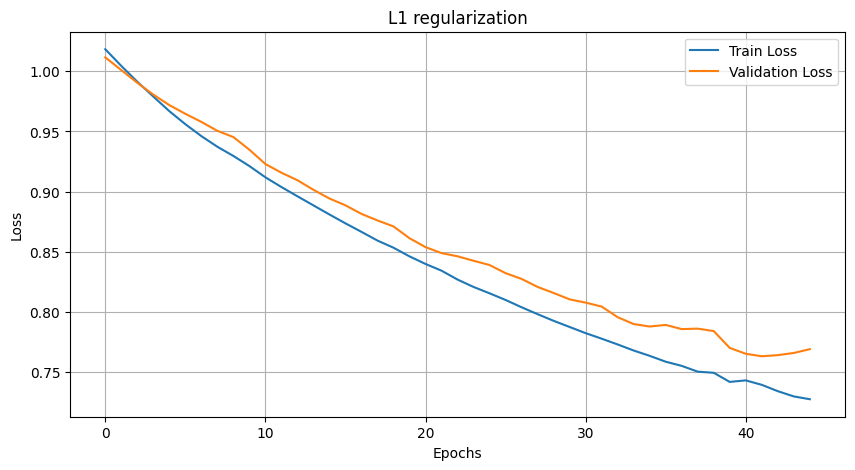

In [29]:
# Make the Neural Network

# L1 Regularization

# Redefine X and Y from the cleaned DataFrame to ensure consistency
X = encoded_df_clean.drop('class', axis=1)
Y = encoded_df_clean['class']

# Perform train-test split to ensure consistency and alignment for this model
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=1)

# Convert pandas DataFrame/Series to numpy arrays
# encoded_df_clean is already fully numeric, so no individual column conversion needed here.
x_train_np = x_train.values
y_train_np = y_train.values
x_test_np = x_test.values
y_test_np = y_test.values

# Define the model with L1 regularization at least 6 hidden layers, at most 9
# The input_dim should match the number of features in x_train
input_dim = x_train_np.shape[1] # Get the number of features from x_train

model_l1 = Sequential([
    Dense(20, input_dim=input_dim, activation='relu'),
    Dense(20, activation='relu', kernel_regularizer=regularizers.l1(0.001)),
    Dense(20, activation='relu', kernel_regularizer=regularizers.l1(0.001)),
    Dense(20, activation='relu', kernel_regularizer=regularizers.l1(0.001)),
    Dense(15, activation='relu', kernel_regularizer=regularizers.l1(0.001)),
    Dense(10, activation='relu', kernel_regularizer=regularizers.l1(0.001)),

    # For binary classification, the output layer should have 1 unit and 'sigmoid' activation
    Dense(1, activation='sigmoid')
])

# Compile the model
# For binary classification with integer labels (0 or 1), use 'binary_crossentropy'
model_l1.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

H = model_l1.fit(
    x_train_np, y_train_np,
    validation_data=(x_test_np, y_test_np),
    epochs=50,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)


plt.figure(figsize=(10, 5))
plt.plot(H.history['loss'], label='Train Loss')
plt.plot(H.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('L1 regularization')
plt.legend()
plt.grid(True)
plt.show()

**Next Plan**
The Merged Dataset didn't work well, so we moved on to only using the German Breast Cancer Study data.

In [30]:
german_df = pd.read_csv("/content/gbsg.csv")
german_df.head()
german_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 686 entries, 0 to 685
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  686 non-null    int64
 1   pid         686 non-null    int64
 2   age         686 non-null    int64
 3   meno        686 non-null    int64
 4   size        686 non-null    int64
 5   grade       686 non-null    int64
 6   nodes       686 non-null    int64
 7   pgr         686 non-null    int64
 8   er          686 non-null    int64
 9   hormon      686 non-null    int64
 10  rfstime     686 non-null    int64
 11  status      686 non-null    int64
dtypes: int64(12)
memory usage: 64.4 KB


In [31]:
X = german_df.drop('status', axis=1)
y = german_df['status']
scaler = StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [32]:
# Baseline Model: Logistic Regression

#split into testing and training:

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(max_iter=1000) # Increased max_iter for convergence
log_reg_model.fit(x_train, y_train)

# Make predictions on the test set
y_pred = log_reg_model.predict(x_test)

# Calculate the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Model Accuracy: {accuracy:.4f}")

Logistic Regression Model Accuracy: 0.7609


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [33]:
model = Sequential()
model.add(Dense(16, input_dim=11, activation = 'relu', kernel_regularizer=l2(0.01)))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
early_stopping = EarlyStopping(monitor='val_loss', patience=2,
                               restore_best_weights=True)
history = model.fit(X_train_scaled, y_train, epochs=10,
                    validation_data=(X_test_scaled, y_test),
                    callbacks=[early_stopping])
y_pred = model.predict(X_test_scaled)
print(y_pred[:20])
y_pred_classes = (y_pred > 0.4).astype(int)
accuracy = accuracy_score(y_test, y_pred_classes)

print(f"Artifical Neural Network Model Accuracy: {accuracy:.4f}")

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5146 - loss: 0.8610 - val_accuracy: 0.5725 - val_loss: 0.8064
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5566 - loss: 0.8170 - val_accuracy: 0.5942 - val_loss: 0.7756
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6022 - loss: 0.7805 - val_accuracy: 0.6159 - val_loss: 0.7530
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6423 - loss: 0.7492 - val_accuracy: 0.6159 - val_loss: 0.7340
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6496 - loss: 0.7420 - val_accuracy: 0.6377 - val_loss: 0.7161
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6241 - loss: 0.7291 - val_accuracy: 0.6594 - val_loss: 0.7009
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6861 - loss: 0.6993 - val_accuracy: 0.6739 - val_loss: 0.6867
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6861 - loss: 0.6905 - val_accuracy: 0.6812 - val_loss: 0.6739
Ep

          Predicted 0  Predicted 1
Actual 0           43           32
Actual 1           13           50


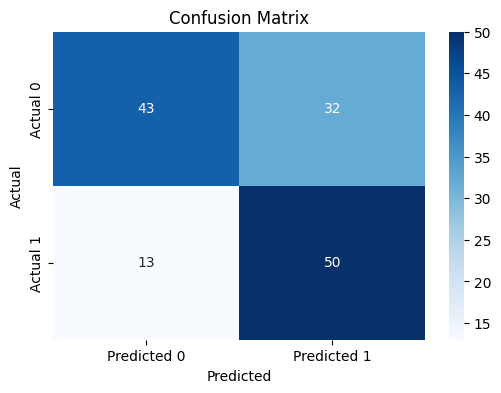

              precision    recall  f1-score   support

           0       0.77      0.57      0.66        75
           1       0.61      0.79      0.69        63

    accuracy                           0.67       138
   macro avg       0.69      0.68      0.67       138
weighted avg       0.70      0.67      0.67       138

Test Accuracy: 0.5435
Final Validation Accuracy from History: 0.7174


In [35]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

# Convert to pandas DataFrame
cm_df = pd.DataFrame(
    cm,
    index=['Actual 0', 'Actual 1'],
    columns=['Predicted 0', 'Predicted 1']
)

print(cm_df)

plt.figure(figsize=(6,4))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(classification_report(y_test, y_pred_classes))

_, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {accuracy:.4f}")

final_val_accuracy = history.history['val_accuracy'][-1]
print(f"Final Validation Accuracy from History: {final_val_accuracy:.4f}")